In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
sns.set_style("whitegrid")

In [2]:
# Load dataset
data_path = "housing.csv"
df = pd.read_csv(data_path)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


In [ ]:
# Clean, prepare data, train model, evaluate
rows_before = df.shape[0]
df = df[df["median_house_value"] >= 0].copy()
print(f"Rows after removing negative targets: {df.shape[0]} (dropped {rows_before - df.shape[0]})")
missing_rows = df[df.isna().any(axis=1)].shape[0]
print(f"Rows with missing values: {missing_rows}")
if missing_rows > 0:
    df = df.dropna()
    print(f"Rows after dropping missing values: {df.shape[0]}")
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
 )
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:,.2f}")
print(f"R^2: {r2:.3f}")
results = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
print(results.head())

RMSE: 70,060.52
R^2: 0.625
       Actual      Predicted
20046   47700   54055.448899
3024    45800  124225.338937
15663  500001  255489.379492
20484  218600  268002.431569
9814   278000  262769.434816
...       ...            ...
15362  263300  220948.486471
16623  266800  244755.654969
18086  500001  439180.983412
2144    72300  120797.552406
3665   151500  183386.049936

[4128 rows x 2 columns]


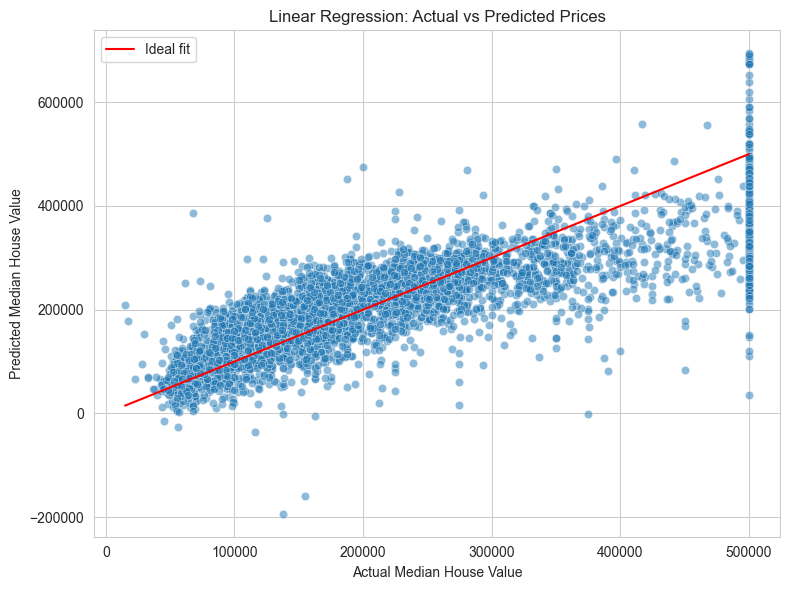

In [4]:
# Plot actual vs predicted prices
plt.figure(figsize=(8, 6))
sns.scatterplot(x=results["Actual"], y=results["Predicted"], alpha=0.5)
sns.lineplot(x=results["Actual"], y=results["Actual"], color="red", label="Ideal fit")
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Linear Regression: Actual vs Predicted Prices")
plt.tight_layout()
plt.show()